# Fase 5 — Análise exploratória do painel PEDE

## tl;dr

- O painel reúne **3.030 observações aluno-ano** de 2022 a 2024; as comparações longitudinais usam apenas os estudantes presentes nos dois anos.
- A defasagem calculada diminui no agregado entre 2022 e 2024, mas isso é uma descrição do painel e **não demonstra causalidade** do programa, pois a composição de estudantes muda a cada ano.
- `INDE` é um índice composto pelos indicadores PEDE. Relações entre seus componentes e o próprio INDE são esperadas mecanicamente e não devem ser usadas como evidência causal.
- `IPP` só está disponível a partir de 2023, e Pedra fornecida diverge da faixa recalculada por INDE. Essas limitações acompanham qualquer conclusão.

Este notebook responde exploratoriamente às questões do Datathon. Ele não treina o modelo preditivo; essa etapa terá validação temporal própria.


## Contexto e método

**Fonte:** `data/processed/pede_painel_consolidado.csv`, gerado da planilha PEDE 2022–2024. O contrato de dados está em `docs/contrato_de_dados.md`.

### Premissas importantes

- O grão é estudante anônimo (`RA`) por ano (`ANO`). `RA` nunca é exibido.
- Defasagem é `FASE - FASE_IDEAL`: valores negativos indicam defasagem.
- Para visualização, usamos as faixas operacionais: em fase/adiantado (`>= 0`), defasagem moderada (`-1`) e severa (`<= -2`). Elas descrevem a distância de fase e não substituem uma classificação clínica/pedagógica oficial.
- Resultados longitudinais são restritos aos estudantes observados nos dois anos; entradas e saídas podem alterar as médias agregadas.
- Correlações mostram associação linear/monotônica na mesma janela. Não identificam causa e efeito.


### Como navegar

A partir da seção **Dados**, o notebook segue as 11 perguntas de negócio oficiais do Datathon, na ordem oficial, cada uma como `### Pergunta N — ...`. Cada pergunta reaproveita a análise já validada e termina com uma conclusão explícita em texto.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
PALETA = {2022: "#315C8D", 2023: "#C58A22", 2024: "#7E9F67"}

raiz = Path.cwd().resolve()
if raiz.name == "notebooks":
    raiz = raiz.parent
sys.path.append(str(raiz))
from src.eda_utils import construir_pares_anos_consecutivos, filtrar_alunos_com_todos_os_anos

caminho_painel = raiz / "data" / "processed" / "pede_painel_consolidado.csv"
painel = pd.read_csv(caminho_painel)

indicadores = ["IAN", "IDA", "IEG", "IAA", "IPS", "IPP", "IPV"]
print(f"Fonte: {caminho_painel.relative_to(raiz)}")
print(f"Grão: aluno-ano | linhas: {len(painel):,} | alunos únicos: {painel['RA'].nunique():,}")
print("Linhas por ano:", painel.groupby("ANO").size().to_dict())


Fonte: data\processed\pede_painel_consolidado.csv
Grão: aluno-ano | linhas: 3,030 | alunos únicos: 1,661
Linhas por ano: {2022: 860, 2023: 1014, 2024: 1156}


## Dados

Antes das perguntas de negócio, verificamos cobertura longitudinal e ausências. O último ano não tem alvo futuro porque a PEDE 2025 não integra a fonte.


In [2]:
anos = sorted(painel["ANO"].unique())
conjunto_ra = {ano: set(painel.loc[painel["ANO"].eq(ano), "RA"]) for ano in anos}

cobertura = []
for origem, destino in zip(anos, anos[1:]):
    comuns = conjunto_ra[origem] & conjunto_ra[destino]
    cobertura.append({
        "Transição": f"{origem}→{destino}",
        "Estudantes nas duas PEDEs": len(comuns),
        "% da coorte de origem": len(comuns) / len(conjunto_ra[origem]),
        "% da coorte de destino": len(comuns) / len(conjunto_ra[destino]),
    })

pd.DataFrame(cobertura).style.format({"% da coorte de origem": "{:.1%}", "% da coorte de destino": "{:.1%}"})


,Transição,Estudantes nas duas PEDEs,% da coorte de origem,% da coorte de destino
0,2022→2023,600,69.8%,59.2%
1,2023→2024,765,75.4%,66.2%


In [3]:
ausencia = (
    painel.groupby("ANO")[indicadores + ["INDE", "PEDRA", "NOTA_INGLES"]]
    .apply(lambda dados: dados.isna().mean())
    .T
    .mul(100)
    .round(1)
)
ausencia.style.format("{:.1f}%").background_gradient(cmap="Oranges", axis=None)


ANO,2022,2023,2024
IAN,0.0%,0.0%,0.0%
IDA,0.0%,7.6%,8.7%
IEG,0.0%,7.5%,0.0%
IAA,0.0%,6.2%,8.8%
IPS,0.0%,6.8%,8.8%
IPP,100.0%,7.5%,8.8%
IPV,0.0%,7.5%,8.8%
INDE,0.0%,8.2%,8.8%
PEDRA,0.0%,8.2%,8.8%
NOTA_INGLES,67.1%,67.1%,59.0%


## Perguntas de negócio

As seções abaixo respondem, em ordem, às 11 perguntas oficiais do Datathon.


### Pergunta 1 — Perfil geral de defasagem (IAN) e evolução ao longo do ano

A análise usa a defasagem calculada, reconciliada com o campo fornecido na etapa de preparação.


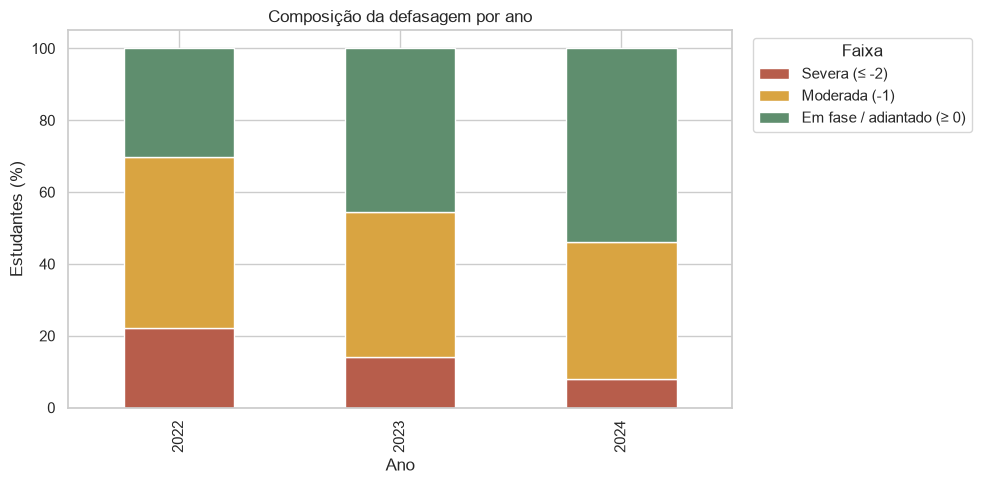

,estudantes,defasagem_media,percentual_defasados,ian_medio
ANO,,,,
2022,860,-0.943000,69.9%,6.424000
2023,1014,-0.655000,54.4%,7.244000
2024,1156,-0.414000,46.2%,7.684000


In [4]:
painel["FAIXA_DEFASAGEM"] = pd.cut(
    painel["DEFASAGEM_CALCULADA"],
    bins=[-np.inf, -2, -1, np.inf],
    labels=["Severa (≤ -2)", "Moderada (-1)", "Em fase / adiantado (≥ 0)"],
)
ordem_faixas = ["Severa (≤ -2)", "Moderada (-1)", "Em fase / adiantado (≥ 0)"]
perfil_defasagem = pd.crosstab(painel["ANO"], painel["FAIXA_DEFASAGEM"], normalize="index").reindex(columns=ordem_faixas)
ax = (perfil_defasagem * 100).plot(kind="bar", stacked=True, figsize=(10, 5), color=["#B75D4B", "#D9A441", "#5F8E6E"])
ax.set(title="Composição da defasagem por ano", xlabel="Ano", ylabel="Estudantes (%)")
ax.legend(title="Faixa", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

resumo_defasagem = painel.groupby("ANO").agg(
    estudantes=("RA", "size"),
    defasagem_media=("DEFASAGEM_CALCULADA", "mean"),
    percentual_defasados=("DEFASAGEM_CALCULADA", lambda serie: (serie < 0).mean()),
    ian_medio=("IAN", "mean"),
).round(3)
resumo_defasagem.style.format({"percentual_defasados": "{:.1%}"})


**Leitura:** a tendência agregada deve ser interpretada junto com a cobertura longitudinal abaixo; médias anuais podem mudar porque a população observada muda.


### Pergunta 2 — Desempenho acadêmico (IDA): melhorando, estagnado ou caindo?

Depois de mapear a defasagem agregada, olhamos a tendência individual do IDA: comparamos cada estudante consigo mesmo entre dois anos consecutivos (coorte pareada), não a média geral da base.


In [ ]:
coortes_pareadas = []
for origem, destino in [(2022, 2023), (2023, 2024)]:
    antes = painel.loc[painel["ANO"].eq(origem), ["RA", "INDE", "IDA", "IEG", "DEFASAGEM_CALCULADA"]]
    depois = painel.loc[painel["ANO"].eq(destino), ["RA", "INDE", "IDA", "IEG", "DEFASAGEM_CALCULADA"]]
    pareado = antes.merge(depois, on="RA", suffixes=("_origem", "_destino"))
    coortes_pareadas.append({
        "Transição": f"{origem}→{destino}",
        "n pareado": len(pareado),
        "INDE médio": (pareado["INDE_destino"] - pareado["INDE_origem"]).mean(),
        "IDA médio": (pareado["IDA_destino"] - pareado["IDA_origem"]).mean(),
        "IEG médio": (pareado["IEG_destino"] - pareado["IEG_origem"]).mean(),
        "defasagem média": (pareado["DEFASAGEM_CALCULADA_destino"] - pareado["DEFASAGEM_CALCULADA_origem"]).mean(),
    })

pd.DataFrame(coortes_pareadas).round(3)


,Transição,n pareado,Δ INDE médio,Δ IDA médio,Δ IEG médio,Δ defasagem média
0,2022→2023,600,-0.025,0.115,0.235,0.157
1,2023→2024,765,-0.050,-0.478,-0.947,0.265


**Leitura:** o IDA médio pareado sobe ligeiramente de 2022 para 2023 (+0,115, n=600) e cai de forma mais acentuada de 2023 para 2024 (-0,478, n=765). O quadro é de estagnação seguida de queda, não de melhoria sustentada — e como as duas transições usam coortes pareadas diferentes (tamanhos de n diferentes), a comparação entre os dois deltas é apenas descritiva, não um teste formal de diferença.


### Pergunta 3 — Engajamento (IEG) x desempenho (IDA) x ponto de virada (IPV)

Na sequência da tendência agregada do IDA, olhamos a relação entre engajamento, desempenho e IPV no mesmo período. O gráfico compara médias descritivas por ano; o espalhamento avalia a associação entre IDA, IEG e IPV.


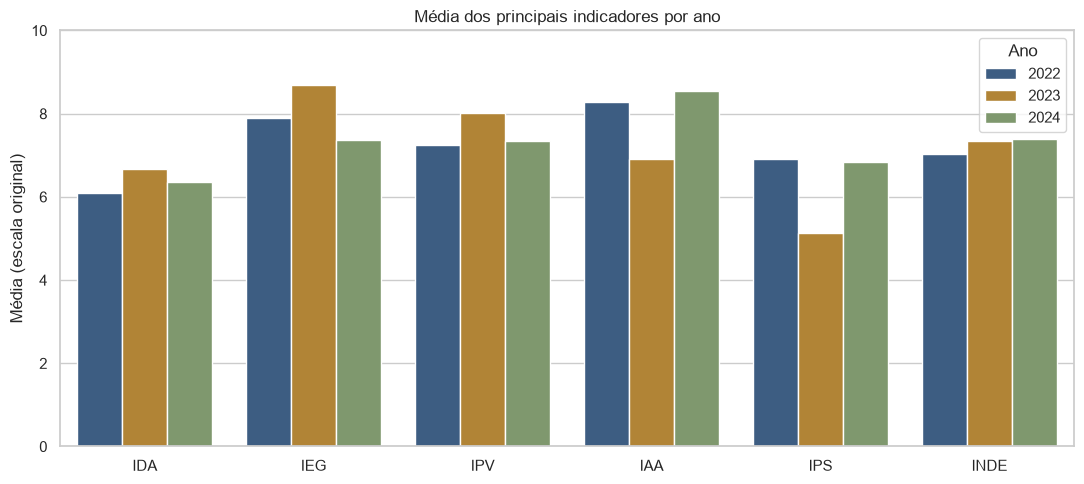

,,IDA,IPV
ANO,Indicador,,
2022,IEG,0.507449,0.540334
2023,IEG,0.446479,0.492018
2024,IEG,0.516812,0.550950


In [6]:
medias = painel.groupby("ANO")[["IDA", "IEG", "IPV", "IAA", "IPS", "INDE"]].mean().reset_index().melt("ANO", var_name="Indicador", value_name="Média")
fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=medias, x="Indicador", y="Média", hue="ANO", palette=PALETA, ax=ax)
ax.set(title="Média dos principais indicadores por ano", xlabel="", ylabel="Média (escala original)")
ax.set_ylim(0, 10)
ax.legend(title="Ano")
plt.tight_layout()
plt.show()

correlacoes_engajamento = (
    painel.groupby("ANO")[["IEG", "IDA", "IPV"]]
    .corr(method="spearman")
    .loc[(slice(None), "IEG"), ["IDA", "IPV"]]
    .rename_axis(index=["ANO", "Indicador"])
)
correlacoes_engajamento


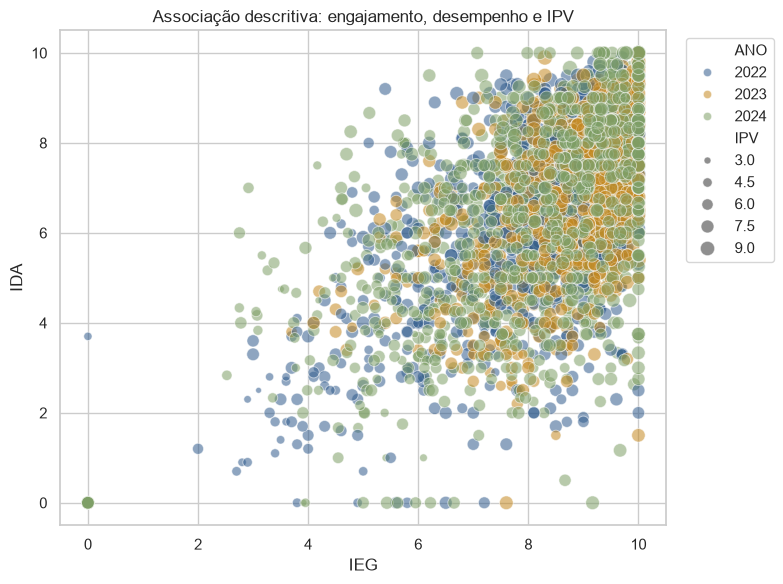

In [7]:
dados_relacao = painel.dropna(subset=["IEG", "IDA", "IPV"])
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=dados_relacao, x="IEG", y="IDA", hue="ANO", size="IPV", sizes=(18, 120), alpha=.55, palette=PALETA, ax=ax)
ax.set(title="Associação descritiva: engajamento, desempenho e IPV", xlabel="IEG", ylabel="IDA")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


**Leitura:** IEG se associa de forma moderada e estável com IDA (Spearman entre 0,45 e 0,52 conforme o ano) e um pouco mais forte com IPV (entre 0,49 e 0,55). O padrão se repete nos três anos, o que reforça que engajamento e desempenho caminham juntos de forma consistente — sempre lembrando que isso é associação, não causa.


### Pergunta 4 — Autoavaliação (IAA) x desempenho real (IDA/IEG) — coerência

Com IDA, IEG e IPV já mapeados, olhamos se o estudante se percebe do jeito que se sai de fato. A matriz usa correlação de Spearman e pares completos em cada coluna. `IPP` deve ser lido apenas no período em que foi coletado (a partir de 2023).


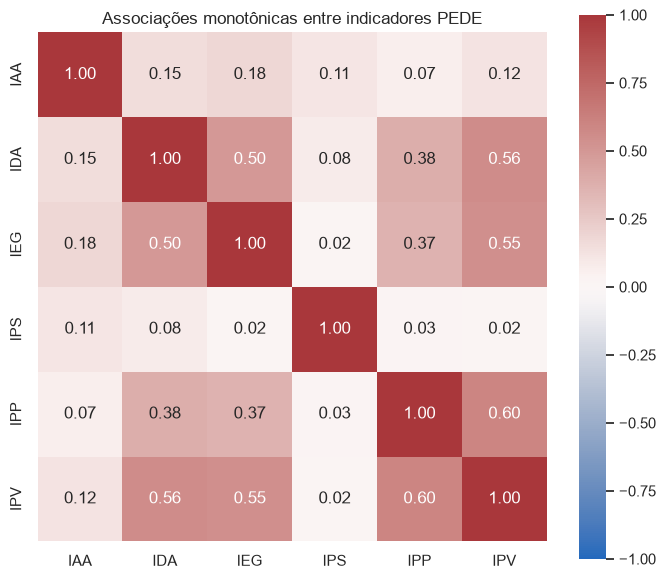

In [8]:
matriz = painel[["IAA", "IDA", "IEG", "IPS", "IPP", "IPV"]].corr(method="spearman")
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(matriz, annot=True, fmt=".2f", cmap="vlag", center=0, vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title("Associações monotônicas entre indicadores PEDE")
plt.tight_layout()
plt.show()


**Leitura:** a autoavaliação (IAA) tem correlação fraca com o desempenho real — Spearman de 0,15 com IDA e 0,18 com IEG. Como o estudante se percebe não é um bom substituto para como ele de fato se sai: a coerência entre autopercepção e desempenho medido é baixa, o que é relevante para quem for usar o IAA como sinal de alerta.


### Pergunta 5 — Padrões psicossociais (IPS) que antecedem quedas de desempenho/engajamento

Testamos se o IPS do ano atual antecipa variações no IDA e no IEG do ano seguinte, usando os mesmos pares de anos consecutivos das perguntas anteriores.


In [9]:
antecedencia = []
for origem, destino in [(2022, 2023), (2023, 2024)]:
    atual = painel.loc[painel["ANO"].eq(origem), ["RA", "IPS", "IDA", "IEG"]]
    proximo = painel.loc[painel["ANO"].eq(destino), ["RA", "IDA", "IEG"]]
    pares = atual.merge(proximo, on="RA", suffixes=("_atual", "_proximo")).dropna()
    pares["DELTA_IDA"] = pares["IDA_proximo"] - pares["IDA_atual"]
    pares["DELTA_IEG"] = pares["IEG_proximo"] - pares["IEG_atual"]
    antecedencia.append({
        "Transição": f"{origem}→{destino}",
        "n": len(pares),
        "Spearman IPS atual × ΔIDA": pares["IPS"].corr(pares["DELTA_IDA"], method="spearman"),
        "Spearman IPS atual × ΔIEG": pares["IPS"].corr(pares["DELTA_IEG"], method="spearman"),
    })

pd.DataFrame(antecedencia).round(3)


,Transição,n,Spearman IPS atual × ΔIDA,Spearman IPS atual × ΔIEG
0,2022→2023,574,0.029,-0.024
1,2023→2024,679,0.027,0.033


**Cuidado de interpretação:** as correlações temporais acima são um sinal exploratório; não isolam intervenções, maturação, mudanças de turma ou a seleção de estudantes que permaneceram na base.


### Pergunta 6 — IPP confirma ou contradiz a defasagem (IAN)?

`IPP` só está disponível a partir de 2023, então a comparação com IAN fica restrita a 2023–2024. Olhamos primeiro a correlação direta entre os dois indicadores e, na sequência, o IPP médio por faixa de defasagem (faixa já calculada na Pergunta 1).


In [10]:
correlacao_ipp_ian = []
for ano in sorted(painel.loc[painel["IPP"].notna(), "ANO"].unique()):
    dados = painel.loc[painel["ANO"].eq(ano), ["IPP", "IAN"]].dropna()
    correlacao_ipp_ian.append({
        "ANO": ano,
        "n": len(dados),
        "Spearman IPP x IAN": dados["IPP"].corr(dados["IAN"], method="spearman"),
    })

pool_ipp_ian = painel.loc[painel["IPP"].notna(), ["IPP", "IAN"]].dropna()
correlacao_ipp_ian.append({
    "ANO": "2023-2024 (agrupado)",
    "n": len(pool_ipp_ian),
    "Spearman IPP x IAN": pool_ipp_ian["IPP"].corr(pool_ipp_ian["IAN"], method="spearman"),
})
pd.DataFrame(correlacao_ipp_ian).round(3)


,ANO,n,Spearman IPP x IAN
0,2023,938,0.106
1,2024,1054,0.160
2,2023-2024 (agrupado),1992,0.131


In [11]:
ipp_defasagem = (
    painel.loc[painel["IPP"].notna()]
    .groupby(["ANO", "FAIXA_DEFASAGEM"], observed=False)["IPP"]
    .agg(["count", "mean", "median"])
    .round(3)
)
ipp_defasagem


count   mean  median
ANO  FAIXA_DEFASAGEM                                
2023 Severa (≤ -2)                144  7.043   7.500
     Moderada (-1)                406  7.650   7.708
     Em fase / adiantado (≥ 0)    388  7.665   7.812
2024 Severa (≤ -2)                 93  7.205   7.292
     Moderada (-1)                441  7.456   7.500
     Em fase / adiantado (≥ 0)    520  7.688   7.708

**Leitura:** a correlação de Spearman entre IPP e IAN é positiva nos dois anos (0,106 em 2023; 0,160 em 2024; 0,131 no agrupado 2023–2024) e a tabela de IPP médio por faixa de defasagem mostra o mesmo padrão — IPP mais alto entre quem está em fase/adiantado, mais baixo entre quem tem defasagem severa, nos dois anos. Ou seja, **IPP confirma o IAN**, na mesma direção, mas com associação fraca a moderada: os dois indicadores não são intercambiáveis, e o IPP sozinho não substitui a defasagem calculada como medida de acompanhamento.


### Pergunta 7 — Quais comportamentos mais influenciam o ponto de virada (IPV)

Até aqui as correlações com IPV (Pergunta 3) foram lidas ano a ano (cross-sectional). Aqui usamos `filtrar_alunos_com_todos_os_anos` (`src/eda_utils.py`) para restringir a análise aos estudantes com registro nos três anos da base — a leitura robusta, em contraste com a leitura cross-sectional das perguntas anteriores.


In [12]:
completos = filtrar_alunos_com_todos_os_anos(painel)
print(
    f"Estudantes com registro em 2022+2023+2024: {completos['RA'].nunique()} de "
    f"{painel['RA'].nunique()} ({completos['RA'].nunique() / painel['RA'].nunique():.1%}) "
    f"— {len(completos)} linhas (não confundir com as 3.030 linhas / 1.661 alunos do painel total)."
)

correlacao_ipv_completos = (
    completos[["IPV", "IEG", "IDA", "IAA", "IPS"]]
    .corr(method="spearman")["IPV"]
    .drop("IPV")
    .sort_values(ascending=False)
)
correlacao_ipv_completos.round(3).to_frame("Spearman com IPV (n=468)")


Estudantes com registro em 2022+2023+2024: 468 de 1661 (28.2%) — 1404 linhas (não confundir com as 3.030 linhas / 1.661 alunos do painel total).


,Spearman com IPV (n=468)
IDA,0.562
IEG,0.539
IAA,0.109
IPS,0.018


**Leitura (n=468, subconjunto com histórico completo):** IDA (0,562) e IEG (0,539) são os comportamentos mais associados ao IPV; IAA (0,109) e IPS (0,018) têm associação fraca a nula. O ranking é o mesmo da leitura cross-sectional da Pergunta 3, o que reforça a robustez do achado: desempenho e engajamento — não autoavaliação ou aspectos psicossociais — são o que mais acompanha o ponto de virada.


### Pergunta 8 — Quais combinações de indicadores (IDA+IEG+IPS+IPP) mais elevam o INDE

Voltamos ao INDE como índice-síntese: quais componentes mais se associam a ele, e como a Pedra resultante se relaciona com o INDE médio. INDE é uma composição dos indicadores avaliados — as associações abaixo ajudam a priorizar investigação, mas não estabelecem que um indicador "causa" o INDE.


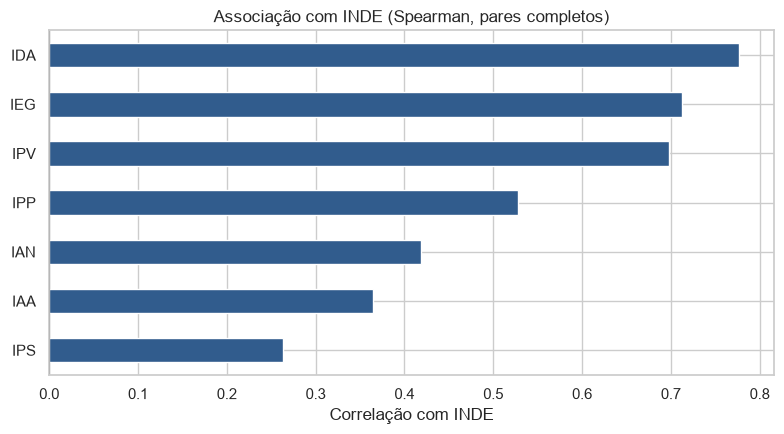

estudantes  inde_medio
ANO  PEDRA                           
2022 AGATA            250       6.606
     AMETISTA         348       7.528
     QUARTZO          132       5.243
     TOPAZIO          130       8.367
2023 AGATA            246       6.569
     AMETISTA         381       7.511
     QUARTZO           72       5.550
     TOPAZIO          232       8.441
     NaN               83         NaN
2024 AGATA            225       6.600
     AMETISTA         391       7.534
     QUARTZO          112       5.400
     TOPAZIO          326       8.468
     NaN              102         NaN

In [13]:
componentes_inde = ["IAN", "IDA", "IEG", "IAA", "IPS", "IPP", "IPV", "INDE"]
correlacao_inde = painel[componentes_inde].corr(method="spearman")["INDE"].drop("INDE").sort_values()
fig, ax = plt.subplots(figsize=(8, 4.5))
correlacao_inde.plot(kind="barh", color="#315C8D", ax=ax)
ax.set(title="Associação com INDE (Spearman, pares completos)", xlabel="Correlação com INDE", ylabel="")
ax.axvline(0, color="#333333", linewidth=0.8)
plt.tight_layout()
plt.show()

pedra_inde = painel.groupby(["ANO", "PEDRA"], dropna=False).agg(estudantes=("RA", "size"), inde_medio=("INDE", "mean")).round(3)
pedra_inde


**Leitura:** IDA (0,777), IEG (0,713) e IPV (0,698) são os componentes mais associados ao INDE; IPP (0,528) e IAN (0,419) vêm na sequência; IAA (0,365) e **IPS (0,264)** são os mais fracos. A tabela de Pedra × INDE médio confirma que a classificação em Pedra acompanha o INDE de forma monotônica (Quartzo < Ágata < Ametista < Topázio). O peso relativo baixo do IPS aqui volta a aparecer na Pergunta 11, cruzado com o achado da Pergunta 5.


### Pergunta 9 — Modelo preditivo de risco de defasagem

Por fim, saindo do exploratório para o preditivo: o alvo disponível mede **risco no próximo ano observado**. Para avaliar "entrada em risco", restringimos a população aos estudantes não defasados no ano atual. Esta seção só resume a base rotulada; o pipeline de modelagem completo (treino, validação temporal, métricas) está no `notebooks/03_modelagem_risco_temporal.ipynb`.


In [14]:
rotulado = painel.dropna(subset=["ALVO_RISCO_DEFASAGEM_PROX_ANO"]).copy()
rotulado["DEFASADO_ATUAL"] = rotulado["DEFASAGEM_CALCULADA"] < 0
risco_futuro = rotulado.groupby("ANO").agg(
    n_rotulado=("RA", "size"),
    risco_futuro=("ALVO_RISCO_DEFASAGEM_PROX_ANO", "mean"),
)
incidencia = (
    rotulado.loc[~rotulado["DEFASADO_ATUAL"]]
    .groupby("ANO")
    .agg(n_nao_defasados=("RA", "size"), incidencia_nova_defasagem=("ALVO_RISCO_DEFASAGEM_PROX_ANO", "mean"))
)
risco_futuro.join(incidencia).style.format({"risco_futuro": "{:.1%}", "incidencia_nova_defasagem": "{:.1%}"})


,n_rotulado,risco_futuro,n_nao_defasados,incidencia_nova_defasagem
ANO,,,,
2022,600,61.0%,189,31.7%
2023,765,40.3%,370,22.7%


**Leitura:** a base rotulada tem cobertura e taxas de risco/incidência diferentes por ano (ver tabela acima); os números completos de performance do modelo, limiares operacionais e validação temporal 2022→2023 (treino) / 2023→2024 (teste) estão no notebook 03 — não são repetidos aqui para evitar divergência entre os dois documentos.


### Pergunta 10 — Efetividade do programa entre fases (Quartzo, Ágata, Ametista, Topázio)

Usamos o mesmo subconjunto de 468 estudantes com histórico completo (Pergunta 7) para comparar a Pedra do primeiro (2022) e do último (2024) ano observado de cada um — uma leitura longitudinal de fato, em vez de média cross-sectional por ano.


In [15]:
ordem_pedra = {"QUARTZO": 0, "AGATA": 1, "AMETISTA": 2, "TOPAZIO": 3}

pedra_2022 = completos.loc[completos["ANO"].eq(2022), ["RA", "PEDRA"]].rename(columns={"PEDRA": "PEDRA_2022"})
pedra_2024 = completos.loc[completos["ANO"].eq(2024), ["RA", "PEDRA"]].rename(columns={"PEDRA": "PEDRA_2024"})
transicao_pedra = pedra_2022.merge(pedra_2024, on="RA")

transicao_valida = transicao_pedra.dropna(subset=["PEDRA_2022", "PEDRA_2024"]).copy()
transicao_valida["ORDEM_2022"] = transicao_valida["PEDRA_2022"].map(ordem_pedra)
transicao_valida["ORDEM_2024"] = transicao_valida["PEDRA_2024"].map(ordem_pedra)
transicao_valida["MUDANCA"] = pd.cut(
    transicao_valida["ORDEM_2024"] - transicao_valida["ORDEM_2022"],
    bins=[-10, -0.5, 0.5, 10],
    labels=["Piorou", "Manteve", "Melhorou"],
)

print(
    f"n = {len(transicao_pedra)} estudantes com histórico completo (2022+2023+2024); "
    f"{len(transicao_valida)} com Pedra registrada em 2022 e 2024 "
    f"({len(transicao_pedra) - len(transicao_valida)} excluídos por Pedra ausente em algum dos dois anos)."
)
resumo_transicao = transicao_valida["MUDANCA"].value_counts().rename("estudantes").to_frame()
resumo_transicao["%"] = (resumo_transicao["estudantes"] / len(transicao_valida) * 100).round(1)
resumo_transicao


n = 468 estudantes com histórico completo (2022+2023+2024); 441 com Pedra registrada em 2022 e 2024 (27 excluídos por Pedra ausente em algum dos dois anos).


,estudantes,%
MUDANCA,,
Manteve,197,44.7
Melhorou,130,29.5
Piorou,114,25.9


In [16]:
pedra_inde  # tabela Pedra x INDE médio por ano, já calculada na Pergunta 8


estudantes  inde_medio
ANO  PEDRA                           
2022 AGATA            250       6.606
     AMETISTA         348       7.528
     QUARTZO          132       5.243
     TOPAZIO          130       8.367
2023 AGATA            246       6.569
     AMETISTA         381       7.511
     QUARTZO           72       5.550
     TOPAZIO          232       8.441
     NaN               83         NaN
2024 AGATA            225       6.600
     AMETISTA         391       7.534
     QUARTZO          112       5.400
     TOPAZIO          326       8.468
     NaN              102         NaN

**Leitura (n=468, mesmo subconjunto da Pergunta 7):** entre os 441 estudantes com Pedra registrada nos dois extremos, 29,5% melhoraram de Pedra entre 2022 e 2024, 44,7% mantiveram a mesma Pedra e 25,9% pioraram. Combinado com o INDE médio por Pedra e por ano (tabela da Pergunta 8), isso indica que o programa acompanha uma parcela relevante dos estudantes com histórico completo em trajetória ascendente ou estável, mas mais de um quarto piora de fase — um sinal para investigar quais perfis pioram, não só quantos.


### Pergunta 11 — Insights livres/criatividade

Fechamos com as conclusões consolidadas de todas as perguntas anteriores, mais um insight que cruza achados de seções diferentes.

1. Priorizar a defasagem calculada como medida de acompanhamento; ela é a base do alvo futuro e tem reconciliação muito alta com a coluna fornecida.
2. Apresentar tendências agregadas junto com coortes pareadas para não confundir mudança de composição com evolução individual.
3. Tratar `IPP`, Inglês, `Indicado` e `Atingiu PV` como disponibilidade desigual por ano — nunca como zero.
4. Não usar Pedra como variável derivada até a Passos Mágicos confirmar a regra atual; manter a classificação fornecida e qualquer regra recalculada separadas.
5. Para o modelo, comparar dois problemas: risco futuro em toda a população observada e incidência de nova defasagem entre quem está em fase. A avaliação principal será 2022→2023 para desenvolvimento e 2023→2024 para teste temporal.


In [17]:
insight_ips_cruzado = pd.Series({
    "IPS x INDE (Pergunta 8, peso no índice)": round(correlacao_inde["IPS"], 3),
    "IPS atual x Δ IDA, 2022→2023 (Pergunta 5)": antecedencia[0]["Spearman IPS atual × ΔIDA"],
    "IPS atual x Δ IDA, 2023→2024 (Pergunta 5)": antecedencia[1]["Spearman IPS atual × ΔIDA"],
    "IPS atual x Δ IEG, 2022→2023 (Pergunta 5)": antecedencia[0]["Spearman IPS atual × ΔIEG"],
    "IPS atual x Δ IEG, 2023→2024 (Pergunta 5)": antecedencia[1]["Spearman IPS atual × ΔIEG"],
})
insight_ips_cruzado.round(3).to_frame("Correlação de Spearman")


,Correlação de Spearman
"IPS x INDE (Pergunta 8, peso no índice)",0.264
"IPS atual x Δ IDA, 2022→2023 (Pergunta 5)",0.029
"IPS atual x Δ IDA, 2023→2024 (Pergunta 5)",0.027
"IPS atual x Δ IEG, 2022→2023 (Pergunta 5)",-0.024
"IPS atual x Δ IEG, 2023→2024 (Pergunta 5)",0.033


6. **Insight novo (cruzando as Perguntas 5 e 8):** o IPS não antecipa quedas de IDA/IEG (correlações próximas de zero na Pergunta 5) e é também o indicador com menor associação ao INDE (Pergunta 8, Spearman ≈ 0,26 — o mais baixo entre os sete componentes). Os dois achados se reforçam: do jeito que é medido hoje, o IPS carrega pouco sinal preditivo e pouco peso relativo no índice — o que sugere ou repensar a forma de coleta do IPS, ou não esperar dele um papel de alerta antecipado de risco enquanto ele permanecer nesse formato.

**Próxima etapa:** validar as decisões pendentes no contrato e construir o notebook de modelagem com métricas de classificação, limiar operacional e explicabilidade apropriada para uso pedagógico.
